plot irrad timescale 

In [2]:
import os
import numpy as np
import sys

import matplotlib.font_manager
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import seaborn
#plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "Helvetica"
plt.rcParams["font.size"] = 22
plt.rcParams["font.weight"] = "normal"

from collections import Counter
from itertools import count
from random import randint
from pathlib import Path
import math

source_p_per_s_per_ua = 6.24151e+12


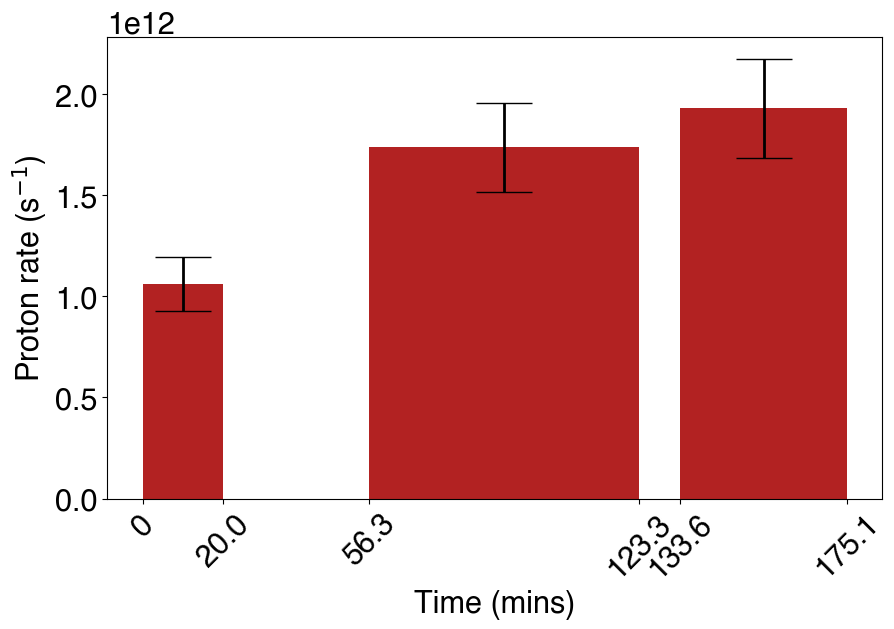

4725135145500.00000
604217206460.52148


In [14]:
# proton irrad timeline

fig, ax1 = plt.subplots()

time_labels = np.array(["0-20", "56.3-123.3", "133.6-175.1"])
fc1_current = np.array([5.5, 9, 10])
target_rate = [i*0.0309*source_p_per_s_per_ua for i in fc1_current]
target_rate_err = [i*0.127873 for i in target_rate]

width = [20,67,41.5]
time_pos = [10,89.8,154.35]

timesteps = [0,20.0,56.3,123.3,133.6,175.1]
centre_timesteps = [10,89.8,154.35]

ax1.bar(time_pos, target_rate, width = width,color='firebrick')
ax1.errorbar(centre_timesteps,target_rate,yerr=target_rate_err,
             ecolor='k',elinewidth=2,capsize=20,linestyle='')
#plt.xticks(time_pos, time_labels)
ax1.set_xticks(timesteps, timesteps,rotation=45)
#ax1.set_yticks([2e10,4e10,6e10,8e10])
ax1.set_xlabel('Time (mins)')
ax1.set_ylabel('Proton rate (s$^{-1}$)')
#ax1.bar_label(ax1.containers[0], label_type='center', color='white')

fig.set_size_inches((10, 6))
plt.show()
fig.savefig('proton_march24/march_irrad_timescale.png', transparent=False, bbox_inches='tight')

print(f'{np.sum(target_rate):.5f}')
#rate_error = np.sqrt(np.sum([i**2 for i in target_rate_err]))/len(target_rate)
rate_error = 0.127873*np.sum(target_rate)
print(f'{rate_error:.5f}')

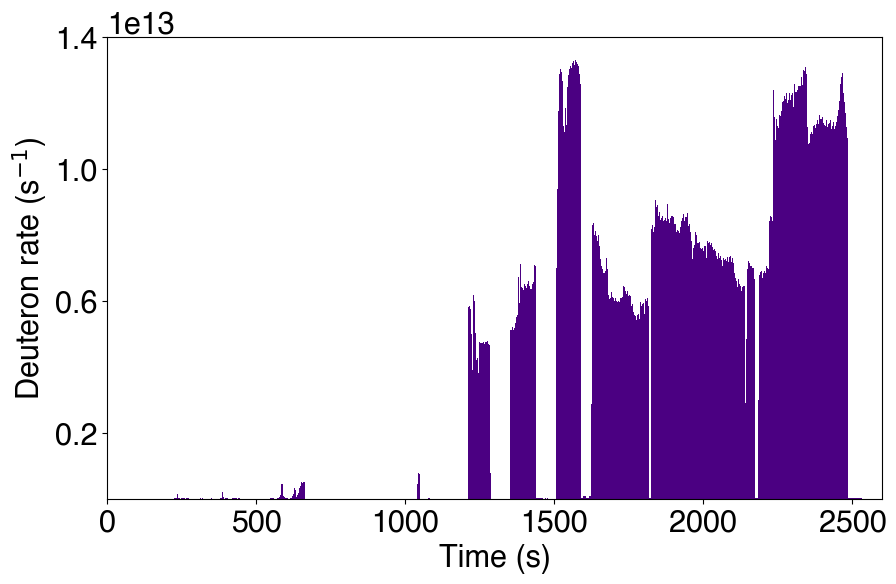

9173187951983136.00000
1110190575801530.25000


In [15]:
# deuteron nov24 irrad timeline
# acquisition start time was 29/11/24 13:46:35
import json

fig, ax1 = plt.subplots()

with open('deuteron_nov24/cup_currents.json'
          ) as deuteron_current_json:
    deuteron_current_data = json.load(deuteron_current_json)
fc1_currents = deuteron_current_data["cup_currents_ua"]
timings = np.ones(5530)
cumulative_timings = np.cumsum(timings)
cumulative_timings_2 = [i-3000 for i in cumulative_timings]
target_rates = np.array([i*0.1850616*source_p_per_s_per_ua for i in fc1_currents])
target_rates_errors = np.array([i*0.1210256 for i in target_rates])

ax1.bar(cumulative_timings_2, target_rates, width = timings,color='indigo')
#ax1.errorbar(cumulative_timings,target_currents,yerr=target_current_errors,ecolor='k',
#             elinewidth=2,capsize=20,linestyle='')
ax1.set_xlim(3000-3000,5600-3000)
#ax1.set_ylim(0,2.5)
ax1.set_yticks([2e12,6e12,10e12,14e12])
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Deuteron rate (s$^{-1}$)')
#ax1.bar_label(ax1.containers[0], label_type='center', color='white')

fig.set_size_inches((10, 6))
plt.show()
fig.savefig('deuteron_nov24/nov24_irrad_timeline.png', transparent=False, bbox_inches='tight')

print(f'{np.sum(target_rates[3000:5600]):.5f}')
#rate_error = np.sqrt(np.sum([i**2 for i in target_rates_errors[3000:5600]]))/len(target_rates[3000:5600])
rate_error = 0.1210256*np.sum(target_rates[3000:5600])
print(f'{rate_error:.5f}')

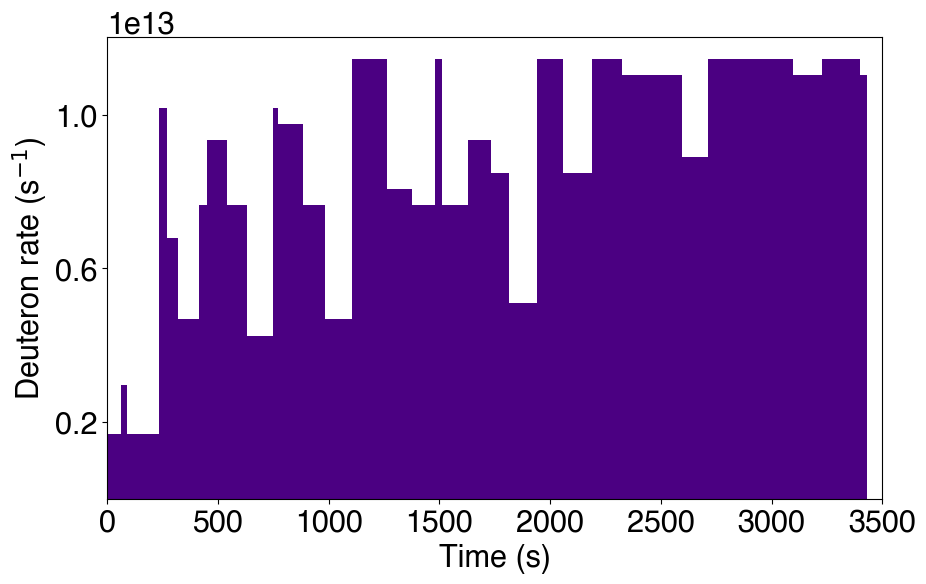

334297522543600.00000
45471149016380.47656


In [16]:
# deuteron sep25 irrad timeline
# 3370 seconds from start 13:58:00 to end 14:54:10

fig, ax1 = plt.subplots()

fc1_currents = [2,3.5,2,12,8,5.5,9,11,9,5,12,11.5,9,5.5,13.5,13.5,9.5,9,13.5,9,11,
                10,6,13.5,13.5,10,13.5,13.5,13,13,10.5,13.5,13.5,13.5,13.5,13,13.5,13]
target_rates = np.array([i*0.13594*source_p_per_s_per_ua for i in fc1_currents])
target_rates_errors = np.array([i*0.13602 for i in target_rates])
timing_widths = [60, 30, 145, 35, 50, 95, 35, 90, 90, 120, 20, 115, 100, 120, 55, 
                 105, 110, 105, 30, 120, 105, 80, 125, 30, 90, 130, 15, 120, 135, 
                 135, 120, 15, 130, 135, 100, 135, 170, 30]
timing_widths_neg = [-x for x in timing_widths]
cumul_timings = np.cumsum(timing_widths)

ax1.bar(cumul_timings, target_rates, width = timing_widths_neg,align='edge',color='indigo')
#ax1.errorbar(cumulative_timings,target_currents,yerr=target_current_errors,ecolor='k',
#             elinewidth=2,capsize=20,linestyle='')
ax1.set_xlim(0,3500)
#ax1.set_ylim(0,3)
ax1.set_yticks([2e12,6e12,10e12])
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Deuteron rate (s$^{-1}$)')
#ax1.bar_label(ax1.containers[0], label_type='center', color='white')

fig.set_size_inches((10, 6))
plt.show()
fig.savefig('deuteron_sep25/sep25_irrad_timeline.png', transparent=False, bbox_inches='tight')

print(f'{np.sum(target_rates):.5f}')
#rate_error = np.sqrt(np.sum([i**2 for i in target_rates_errors]))/len(target_rates)
rate_error = 0.13602*np.sum(target_rates)
print(f'{rate_error:.5f}')